# GPU-Accelerated Semiconductor Wafer Defect Classification

This project develops a PyTorch computer-vision model to classify semiconductor
wafer-map failure patterns. Model training and inference will be accelerated using
an NVIDIA GPU through CUDA and benchmarked against CPU execution.

Dataset: WM-811K Wafer Map Dataset from Kaggle

In [1]:
import time
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# Check whether PyTorch can access an NVIDIA GPU.
gpu_available = torch.cuda.is_available()

# Choose the GPU if available; otherwise choose the CPU.
device = torch.device("cuda" if gpu_available else "cpu")

print("PyTorch version:", torch.__version__)
print("CUDA available:", gpu_available)
print("Selected device:", device)

# Only ask for the GPU's name if a GPU is available.
if gpu_available:
    print("GPU name:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu130
CUDA available: True
Selected device: cuda
GPU name: Tesla T4


In [6]:
from google.colab import drive
from pathlib import Path

# Connect Google Drive.
drive.mount("/content/drive")

# Match my existing folder names.
project_folder = Path("/content/drive/MyDrive/wafer_defect_project")

data_folder = project_folder / "Data"
checkpoint_folder = project_folder / "Checkpoints"
results_folder = project_folder / "Results"

# Check that Colab can find each folder.
for folder in [data_folder, checkpoint_folder, results_folder]:
    print(f"{folder.name}: {folder.is_dir()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data: True
Checkpoints: True
Results: True


In [7]:
# Build the path to the dataset file.
dataset_path = data_folder / "LSWMD.pkl"

# Check whether the file is accessible.
print("Dataset path:", dataset_path)
print("File found:", dataset_path.is_file())

# Display its size if it exists.
if dataset_path.is_file():
    size_mb = dataset_path.stat().st_size / (1024 ** 2)
    print(f"File size: {size_mb:.1f} MB")

Dataset path: /content/drive/MyDrive/wafer_defect_project/Data/LSWMD.pkl
File found: True
File size: 1998.4 MB


In [9]:
import pandas as pd

df = pd.read_pickle(dataset_path)

print("Dataset loaded successfully!")
print("Rows and columns:", df.shape)
print("Column names:", df.columns.tolist())

display(df.head(3))

Dataset loaded successfully!
Rows and columns: (811457, 6)
Column names: ['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel', 'failureType']


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]


Map shape: (45, 48)
Unique cell values: [0 1 2]
Stored label: [['none']]


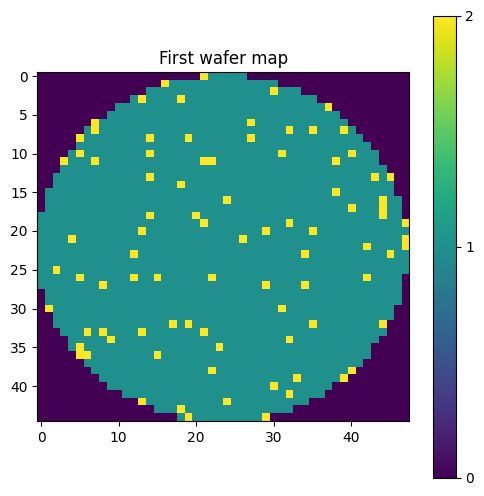

In [10]:
# Select the first row of the table.
first_wafer = df.iloc[0]

# Retrieve its wafer-map array.
wafer_map = first_wafer["waferMap"]

print("Map shape:", wafer_map.shape)
print("Unique cell values:", np.unique(wafer_map))
print("Stored label:", first_wafer["failureType"])

# Display the numerical array as an image.
plt.figure(figsize=(6, 6))
plt.imshow(
    wafer_map,
    interpolation="nearest",
    vmin=0,
    vmax=2
)
plt.title("First wafer map")
plt.colorbar(ticks=[0, 1, 2])
plt.show()

In [11]:
# Convert one stored label into a plain string.
def clean_label(stored_label):
    values = np.asarray(stored_label).flatten()

    if values.size == 0:
        return None

    return str(values[0])

# Create a new column while keeping the original.
df["label"] = df["failureType"].apply(clean_label)

# Compare the original and cleaned labels.
display(df[["failureType", "label"]].head(5))

# Count each category, including missing labels.
print(df["label"].value_counts(dropna=False))

,failureType,label
0,[[none]],none
1,[[none]],none
2,[[none]],none
3,[[none]],none
4,[[none]],none


label
None         638507
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


In [12]:
# Select rows that have a known label.
labeled_df = df.loc[df["label"].notna()].copy()

print("Original number of wafers:", len(df))
print("Labeled wafers:", len(labeled_df))
print("Excluded unlabeled wafers:", len(df) - len(labeled_df))
print("Number of categories:", labeled_df["label"].nunique())

print("\nCategory counts:")
print(labeled_df["label"].value_counts())

Original number of wafers: 811457
Labeled wafers: 172950
Excluded unlabeled wafers: 638507
Number of categories: 9

Category counts:
label
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


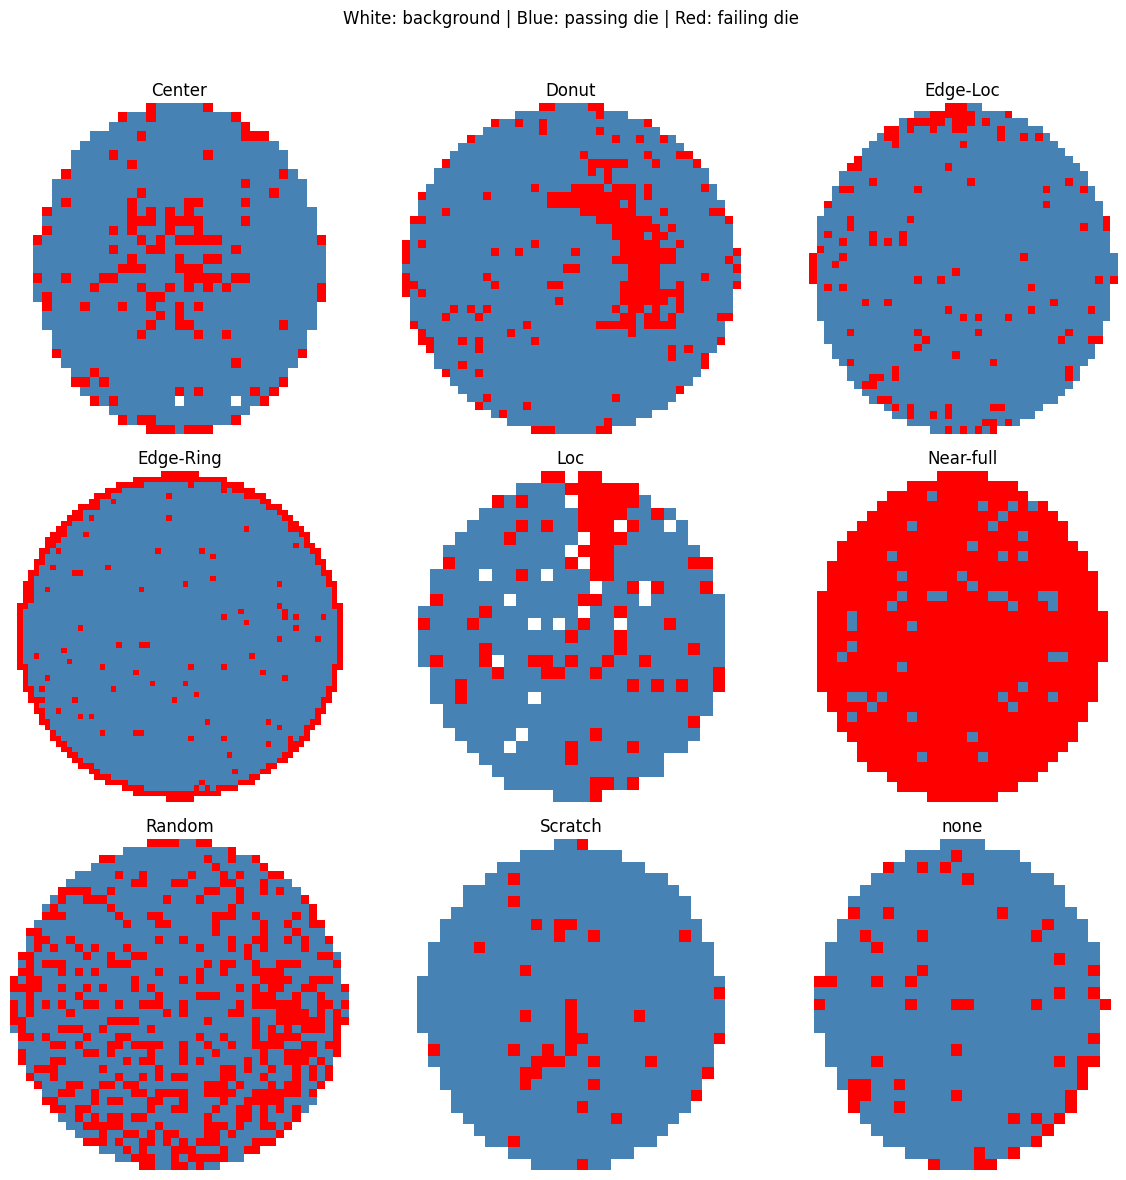

In [13]:
from matplotlib.colors import ListedColormap

wafer_colors = ListedColormap(["white", "steelblue", "red"])

# Get the nine category names in alphabetical order.
class_names = sorted(labeled_df["label"].unique())

# Create a figure containing nine plots.
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for ax, class_name in zip(axes.flat, class_names):
    # Select the rows belonging to this category.
    class_rows = labeled_df.loc[
        labeled_df["label"] == class_name
    ]

    # Pick one reproducible example.
    example = class_rows.sample(n=1, random_state=42).iloc[0]

    # Display its wafer map.
    ax.imshow(
        example["waferMap"],
        cmap=wafer_colors,
        vmin=0,
        vmax=2,
        interpolation="nearest"
    )
    ax.set_title(class_name)
    ax.axis("off")

fig.suptitle(
    "White: background | Blue: passing die | Red: failing die"
)
fig.tight_layout(rect=[0, 0, 1, 0.96])

# Save the figure to your existing Results folder.
fig.savefig(results_folder / "wafer_class_examples.png", dpi=150)

plt.show()

In [14]:
# Check whether manufacturing-lot identifiers are available.
print("Labeled wafers:", len(labeled_df))
print("Unique lots:", labeled_df["lotName"].nunique())
print("Missing lot names:", labeled_df["lotName"].isna().sum())

# Count how many different lots contain each category.
lots_per_class = (
    labeled_df.groupby("label")["lotName"]
    .nunique()
    .sort_values()
)

print("\nNumber of lots containing each category:")
print(lots_per_class)

# Inspect the training/test assignments supplied with the dataset.
original_split = labeled_df["trianTestLabel"].apply(clean_label)

print("\nOriginal dataset assignments:")
print(original_split.value_counts(dropna=False))

Labeled wafers: 172950
Unique lots: 10762
Missing lot names: 0

Number of lots containing each category:
label
Near-full     137
Donut         233
Random        449
Scratch      1059
Edge-Ring    1075
Center       1648
Loc          2472
Edge-Loc     3211
none         6591
Name: lotName, dtype: int64

Original dataset assignments:
trianTestLabel
Test        118595
Training     54355
Name: count, dtype: int64


In [15]:
from sklearn.model_selection import GroupShuffleSplit

# First: assign about 70% of lots to training.
first_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=42
)

train_positions, remaining_positions = next(
    first_split.split(
        labeled_df,
        groups=labeled_df["lotName"]
    )
)

train_df = labeled_df.iloc[train_positions].copy()
remaining_df = labeled_df.iloc[remaining_positions].copy()

# Second: divide the remaining lots equally between validation and test.
second_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=42
)

val_positions, test_positions = next(
    second_split.split(
        remaining_df,
        groups=remaining_df["lotName"]
    )
)

val_df = remaining_df.iloc[val_positions].copy()
test_df = remaining_df.iloc[test_positions].copy()

In [16]:
# Show the number and percentage of wafers in each partition.
for name, partition in [
    ("Training", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    percentage = 100 * len(partition) / len(labeled_df)
    print(f"{name}: {len(partition):,} wafers ({percentage:.1f}%)")

# Compare category counts across the three partitions.
class_counts = pd.DataFrame({
    "Training": train_df["label"].value_counts(),
    "Validation": val_df["label"].value_counts(),
    "Test": test_df["label"].value_counts()
}).fillna(0).astype(int)

display(class_counts)

# Check that no manufacturing lot appears in two partitions.
train_lots = set(train_df["lotName"])
val_lots = set(val_df["lotName"])
test_lots = set(test_df["lotName"])

assert train_lots.isdisjoint(val_lots)
assert train_lots.isdisjoint(test_lots)
assert val_lots.isdisjoint(test_lots)

assert (class_counts > 0).all().all(), "A partition is missing a category."

print("Checks passed: no shared lots, and all categories are present.")

Training: 120,979 wafers (70.0%)
Validation: 26,116 wafers (15.1%)
Test: 25,855 wafers (14.9%)


,Training,Validation,Test
label,,,
none,103101,22264,22066
Edge-Ring,6871,1377,1432
Edge-Loc,3630,787,772
Center,3008,683,603
Loc,2411,606,576
Scratch,871,145,177
Random,614,121,131
Donut,366,106,83
Near-full,107,27,15


Checks passed: no shared lots, and all categories are present.


In [17]:
import hashlib

# Create a fingerprint from a map's shape and cell values.
def map_fingerprint(wafer_map):
    array = np.asarray(wafer_map, dtype=np.uint8)

    shape_bytes = str(array.shape).encode("utf-8")
    map_bytes = array.tobytes()

    return hashlib.sha256(shape_bytes + map_bytes).hexdigest()

# Calculate one fingerprint per wafer map.
for partition in [train_df, val_df, test_df]:
    partition["map_hash"] = partition["waferMap"].apply(
        map_fingerprint
    )

# Collect the distinct fingerprints in each partition.
train_hashes = set(train_df["map_hash"])
val_hashes = set(val_df["map_hash"])
test_hashes = set(test_df["map_hash"])

print("Shared unique maps:")
print("Train / Validation:", len(train_hashes & val_hashes))
print("Train / Test:", len(train_hashes & test_hashes))
print("Validation / Test:", len(val_hashes & test_hashes))

Shared unique maps:
Train / Validation: 682
Train / Test: 705
Validation / Test: 163


In [18]:
# Combine only the metadata needed for this check.
# We do not copy the large wafer-map arrays.
map_records = pd.concat([
    train_df[["map_hash", "label"]].assign(split="Training"),
    val_df[["map_hash", "label"]].assign(split="Validation"),
    test_df[["map_hash", "label"]].assign(split="Test")
])

# Collect fingerprints shared between any two partitions.
shared_hashes = (
    (train_hashes & val_hashes)
    | (train_hashes & test_hashes)
    | (val_hashes & test_hashes)
)

# Select every record whose map appears across partitions.
shared_records = map_records.loc[
    map_records["map_hash"].isin(shared_hashes)
]

print("Distinct maps shared across partitions:", len(shared_hashes))

print("\nAffected wafer records by category and partition:")
display(pd.crosstab(
    shared_records["label"],
    shared_records["split"]
))

# Check whether identical maps have different category labels.
labels_per_map = shared_records.groupby("map_hash")["label"].nunique()

print(
    "\nShared maps with conflicting labels:",
    (labels_per_map > 1).sum()
)

Distinct maps shared across partitions: 1550

Affected wafer records by category and partition:


split,Test,Training,Validation
label,,,
Center,2,4,2
Edge-Loc,10,13,10
Edge-Ring,2,4,4
Loc,5,7,3
Near-full,3,5,3
Random,4,6,2
Scratch,3,4,1
none,840,1345,820



Shared maps with conflicting labels: 4


In [19]:
# Check for conflicting labels across ALL records,
# including duplicates within a single partition.
label_counts = map_records.groupby("map_hash")["label"].nunique()
conflicting_hashes = set(label_counts[label_counts > 1].index)

print("Maps with conflicting labels:", len(conflicting_hashes))

# Exclude ambiguous maps from every partition.
train_clean = train_df.loc[
    ~train_df["map_hash"].isin(conflicting_hashes)
].copy()

val_clean = val_df.loc[
    ~val_df["map_hash"].isin(conflicting_hashes)
].copy()

test_clean = test_df.loc[
    ~test_df["map_hash"].isin(conflicting_hashes)
].copy()

# Test takes priority: remove its matching maps from validation.
test_map_hashes = set(test_clean["map_hash"])

val_clean = val_clean.loc[
    ~val_clean["map_hash"].isin(test_map_hashes)
].copy()

# Remove maps from training if they appear in either held-out set.
held_out_hashes = test_map_hashes | set(val_clean["map_hash"])

train_clean = train_clean.loc[
    ~train_clean["map_hash"].isin(held_out_hashes)
].copy()

Maps with conflicting labels: 14


In [20]:
# Report how many rows were excluded.
for name, original, cleaned in [
    ("Training", train_df, train_clean),
    ("Validation", val_df, val_clean),
    ("Test", test_df, test_clean)
]:
    print(
        f"{name}: {len(cleaned):,} remaining; "
        f"{len(original) - len(cleaned):,} excluded"
    )

# Verify both map separation and lot separation.
for column in ["map_hash", "lotName"]:
    train_values = set(train_clean[column])
    val_values = set(val_clean[column])
    test_values = set(test_clean[column])

    assert train_values.isdisjoint(val_values)
    assert train_values.isdisjoint(test_values)
    assert val_values.isdisjoint(test_values)

# Check that all nine categories remain in each partition.
clean_counts = pd.DataFrame({
    "Training": train_clean["label"].value_counts(),
    "Validation": val_clean["label"].value_counts(),
    "Test": test_clean["label"].value_counts()
}).reindex(class_names).fillna(0).astype(int)

display(clean_counts)

assert (clean_counts > 0).all().all(), "A category is missing."

print("Checks passed: no shared maps or lots; all categories remain.")

Training: 119,573 remaining; 1,406 excluded
Validation: 25,949 remaining; 167 excluded
Test: 25,853 remaining; 2 excluded


,Training,Validation,Test
label,,,
Center,3003,683,602
Donut,366,106,83
Edge-Loc,3610,782,772
Edge-Ring,6865,1376,1432
Loc,2402,606,575
Near-full,102,26,15
Random,608,121,131
Scratch,867,145,177
none,101750,22104,22066


Checks passed: no shared maps or lots; all categories remain.
